<a href="https://colab.research.google.com/github/ClaudiaTurner/GEOG5990M/blob/main/Final_Project_Python_GEOG5990M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment (Template)

Student ID number: 201893759

In [ ]:
# read in required packages

This is an example block of mardown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>



Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

In [1]:
# To begin, I will import the packages I will use in block 1


import pandas as pd  # Used for uploading and handling data (e.g., upload CSV) (Nelli, 2023).

import matplotlib.pyplot as plt  # Used for creating visualisations (e.g., line chart) (Walker, 2020).

import numpy as np  # Used for numerical operations (e.g., create a range of years) (Walker, 2020).

import seaborn as sns  # Makes it easier to create attractive and informative statistical graphics (e.g., barplot) (Rajagopalan,2021)




In [2]:
# LOAD DATA
#The DataFrame contains information on house sales from 1996 to 2023, across all districts in England. Our analysis will cover 2013 to 2023.
# To upload the data (CSV), I’ll paste the GitHub file path below:

Sales_England=pd.read_csv('https://github.com/ClaudiaTurner/GEOG5990M/raw/main/DATA/Eng_sales_1996_2023_.csv')


# To understand the data better, I'll take a quick look at the first six rows

display(Sales_England.head(6))

# I added row and column info below the table, with a title and a line break for clarity.
print('\nNumber of rows and columns:')
print(Sales_England.shape)


,Residential property sales,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,ONS Crown Copyright Reserved [from Nomis on 9 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Count of sales:,Sales,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Area,mnemonic,row,Sep-96,Sep-97,Sep-98,Sep-99,Sep-00,Sep-01,Sep-02,...,Sep-14,Sep-15,Sep-16,Sep-17,Sep-18,Sep-19,Sep-20,Sep-21,Sep-22,Sep-23
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,country:England,E92000001,1,850013,1047268,1016037,1084672,1130983,1133620,1271168,...,877425,854379,903005,852771,829715,803012,669410,1081660,787290,573646



Number of rows and columns:
(324, 31)


In [3]:
# The original CSV had extra information in rows 1, 2, 3, and 4, making the data messy.
# For example, 'Unnamed: 1' was just a blank row in the original file.
# The column titles should be in the fifth row — years like 'Sep-96', 'Area', etc.
## To clean the data, I will start by removing the first four rows using the 'skiprows' function (Walker, 2020).
## This will eliminate everything above the actual headers.

Sales_England = pd.read_csv('https://github.com/ClaudiaTurner/GEOG5990M/raw/main/Sales_1995_2023_England_Districts_exp.csv', skiprows=4)

# Confirm the changes
Sales_England.head()


,row,Sep-96,Sep-97,Sep-98,Sep-99,Sep-00,Sep-01,Sep-02,Sep-03,Sep-04,...,Sep-16,Sep-17,Sep-18,Sep-19,Sep-20,Sep-21,Sep-22,Sep-23,Area,mnemonic
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,850013.0,1047268.0,1016037.0,1084672.0,1130983.0,1133620.0,1271168.0,1153345.0,1264229.0,...,903005.0,852771.0,829715.0,803012.0,669410.0,1081660.0,787290.0,573646.0,country:England,E92000001
2,2.0,1159.0,1390.0,1405.0,1440.0,1726.0,2140.0,2359.0,2488.0,2979.0,...,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,ladu2023:Hartlepool,E06000001
3,3.0,1776.0,1934.0,1948.0,2055.0,2280.0,2462.0,2826.0,3016.0,3339.0,...,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,ladu2023:Middlesbrough,E06000002
4,4.0,1879.0,2000.0,1957.0,1986.0,2266.0,2582.0,3497.0,3390.0,3138.0,...,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,ladu2023:Redcar and Cleveland,E06000003


In [4]:
# Our analysis should only include the past ten years (2013 - 2023), hence we can eliminate the rest of the years
# Additionally, we also eliminate 'row' because we already have the table's row enumeration
Sales_England = Sales_England.drop(columns=[
    'row', 'Sep-96', 'Sep-97', 'Sep-98', 'Sep-99',
    'Sep-00', 'Sep-01', 'Sep-02', 'Sep-03', 'Sep-04',
    'Sep-05', 'Sep-06', 'Sep-07', 'Sep-08', 'Sep-09',
    'Sep-10', 'Sep-11', 'Sep-12'])

# After eliminating many columns, ill check if the columns were successfully eliminated
Sales_England.columns.tolist()   # .tolist() converts the column index into a regular Python list

['Sep-13',
 'Sep-14',
 'Sep-15',
 'Sep-16',
 'Sep-17',
 'Sep-18',
 'Sep-19',
 'Sep-20',
 'Sep-21',
 'Sep-22',
 'Sep-23',
 'Area',
 'mnemonic']

In [5]:
# To further clean and enhance the data, I'll rename and reorder the columns.
# I'll also change the date format from 'Sep-13' to '2013' for all years to improve readability. # To update the file, I can use either 'Sales_England =' or set 'inplace=True'.

Sales_England = Sales_England.rename(columns={
  'Sep-13': '2013', 'Sep-14': '2014', 'Sep-15': '2015', 'Sep-16': '2016', 'Sep-17': '2017',
    'Sep-18': '2018','Sep-19': '2019','Sep-20': '2020','Sep-21': '2021','Sep-22': '2022','Sep-23': '2023','Area': 'DISTRICT','mnemonic': 'CODE_LAD'})

# 2. Reorder the columns so that the district name and code appear before the years.
# After runing this code: 'Sales_England = Sales_England[['DISTRICT', 'CODE_LAD'] + [str(y) for y in range(2013, 2023)]]', year 2023 disappeared
## Thus I asked Copilot (ADD VERSION): 'After introducing the code, year 2023 is not visible, why?'
## Copilot:  in Python, range(...) excludes the end value, so 2023 is not included.

Sales_England = Sales_England[['DISTRICT', 'CODE_LAD'] + [str(y) for y in range(2013, 2024)]]


# Check the last 5 rows to confirm changes.
Sales_England.tail()


,DISTRICT,CODE_LAD,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
315,ladu2023:Torfaen,W06000020,905.0,1091.0,985.0,1103.0,1324.0,1438.0,1464.0,1060.0,1520.0,1392.0
316,ladu2023:Monmouthshire,W06000021,1260.0,1413.0,1399.0,1584.0,1557.0,1482.0,1307.0,1054.0,1936.0,1556.0
317,ladu2023:Newport,W06000022,1496.0,2016.0,2178.0,2761.0,3021.0,2869.0,2503.0,1798.0,2634.0,2440.0
318,ladu2023:Powys,W06000023,1334.0,1650.0,1635.0,1743.0,1827.0,1880.0,1802.0,1383.0,2394.0,1831.0
319,ladu2023:Merthyr Tydfil,W06000024,520.0,683.0,706.0,786.0,745.0,682.0,725.0,577.0,818.0,781.0


In [ ]:
#Sales_England.dtypes

In [6]:
# Search for null values
# Explain why we have null values
Sales_England.isnull().sum()

,0
DISTRICT,1
CODE_LAD,1
2013,1
2014,1
2015,1
2016,1
2017,1
2018,1
2019,1
2020,1


In [7]:
# Eliminate null values
Sales_England = Sales_England.dropna()

# .info() shows column names, data types, non-null counts, and memory usage (Walker, 2020.
Sales_England.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319 entries, 1 to 319
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DISTRICT  319 non-null    object 
 1   CODE_LAD  319 non-null    object 
 2   2013      319 non-null    float64
 3   2014      319 non-null    float64
 4   2015      319 non-null    float64
 5   2016      319 non-null    float64
 6   2017      319 non-null    float64
 7   2018      319 non-null    float64
 8   2019      319 non-null    float64
 9   2020      319 non-null    float64
 10  2021      319 non-null    float64
 11  2022      319 non-null    float64
dtypes: float64(10), object(2)
memory usage: 32.4+ KB


In [8]:
# Drop the first row (Country: England) by specifying its index.
# We're removing it because the data is unclear and not useful.
# Later on, we'll create a new row to calculate the total amount per year. index[0] selects the first row in the table.

Sales_England = Sales_England.drop(Sales_England.index[0]).reset_index(drop=True) # .reset_index(drop=True) resets row numbering to start at 0
                                                                                  # e.g., instead of index 1, 2, 3... → becomes 0, 1, 2...

# The first row has now been removed. Check the first 3 rows to confirm.
Sales_England.head(3)


,DISTRICT,CODE_LAD,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,ladu2023:Hartlepool,E06000001,919.0,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0
1,ladu2023:Middlesbrough,E06000002,1271.0,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0
2,ladu2023:Redcar and Cleveland,E06000003,1418.0,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0


In [9]:
# Additionally, I'll remove the 'ladu2023:' prefix from all values in the 'DISTRICT' column to clean up the district names.

Sales_England['DISTRICT'] = Sales_England['DISTRICT'].str.replace('ladu2023:', '')

# The prefix in the district names is no longer visible. Briefly check the first 5 rowa
Sales_England.head()

,DISTRICT,CODE_LAD,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Hartlepool,E06000001,919.0,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0
1,Middlesbrough,E06000002,1271.0,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0
2,Redcar and Cleveland,E06000003,1418.0,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0
3,Stockton-on-Tees,E06000004,2390.0,2724.0,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0
4,Darlington,E06000005,1294.0,1589.0,1705.0,1679.0,1642.0,1602.0,1616.0,1501.0,2435.0,1885.0


In [10]:
#Before calculating the total sales amount per district,

# 1. Identify year columns (float64 type, excluding metadata e.g.,'DISTRICT')
year_columns = Sales_England.select_dtypes(include='number').columns

# 2. Sum across those columns for each row
Sales_England['TOTAL_SALES_LAD_'] = Sales_England[year_columns].sum(axis=1)
Sales_England.head(4)

,DISTRICT,CODE_LAD,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,TOTAL_SALES_LAD_
0,Hartlepool,E06000001,919.0,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,12527.0
1,Middlesbrough,E06000002,1271.0,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,17672.0
2,Redcar and Cleveland,E06000003,1418.0,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,19110.0
3,Stockton-on-Tees,E06000004,2390.0,2724.0,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,29248.0


In [41]:

# 1. Get only the year columns (2013–2023)
# 1. Define year columns only
# 1. Define only the actual year columns (2013–2022)
year_cols = [str(y) for y in range(2013, 2024)]  # Only 10 years

# 2. Calculate the average across just those 10 years
Sales_England['AVERAGE'] = Sales_England[year_cols].mean(axis=1)

Sales_England.head(4)

,DISTRICT,CODE_LAD,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,TOTAL_SALES_LAD_,AVERAGE
0,Hartlepool,E06000001,919.0,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,12527.0,1252.7
1,Middlesbrough,E06000002,1271.0,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,17672.0,1767.2
2,Redcar and Cleveland,E06000003,1418.0,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,19110.0,1911.0
3,Stockton-on-Tees,E06000004,2390.0,2724.0,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,29248.0,2924.8


In [ ]:
# maybe here add total amount of england per year, also adding the average summ that should match the total...

In [11]:
#
#EXPLAIN THE DETAILS BETTER

#Calculat total amount per year
# 1. Identify numeric and non-numeric columns
numeric_cols = Sales_England.select_dtypes(include='number').columns
non_numeric_cols = [col for col in Sales_England.columns if col not in numeric_cols]

# 2. Sum only numeric columns
england_totals = Sales_England[numeric_cols].sum()

# 3. Add placeholders (e.g., 'England') for non-numeric columns
for col in non_numeric_cols:
    england_totals[col] = 'ENGLAND_TOTAL_YEAR'

# 4. Reorder columns to match the original DataFrame
england_totals = england_totals[Sales_England.columns]

# 5. Append the row
Sales_England = pd.concat([Sales_England, pd.DataFrame([england_totals])], ignore_index=True)
Sales_England.tail()

,DISTRICT,CODE_LAD,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,TOTAL_SALES_LAD_
314,Monmouthshire,W06000021,1260.0,1413.0,1399.0,1584.0,1557.0,1482.0,1307.0,1054.0,1936.0,1556.0,14548.0
315,Newport,W06000022,1496.0,2016.0,2178.0,2761.0,3021.0,2869.0,2503.0,1798.0,2634.0,2440.0,23716.0
316,Powys,W06000023,1334.0,1650.0,1635.0,1743.0,1827.0,1880.0,1802.0,1383.0,2394.0,1831.0,17479.0
317,Merthyr Tydfil,W06000024,520.0,683.0,706.0,786.0,745.0,682.0,725.0,577.0,818.0,781.0,7023.0
318,ENGLAND_TOTAL_YEAR,ENGLAND_TOTAL_YEAR,732330.0,919730.0,896482.0,948962.0,899937.0,877152.0,849682.0,704696.0,1135971.0,833859.0,8798801.0


<ipython-input-27-70f402d43cc6>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_data.index, y=year_data.values, palette='Blues_d')


Text(0.5, 1.0, 'TOTAL PROPERTY SALES IN ENGLAND (2013–2023)')

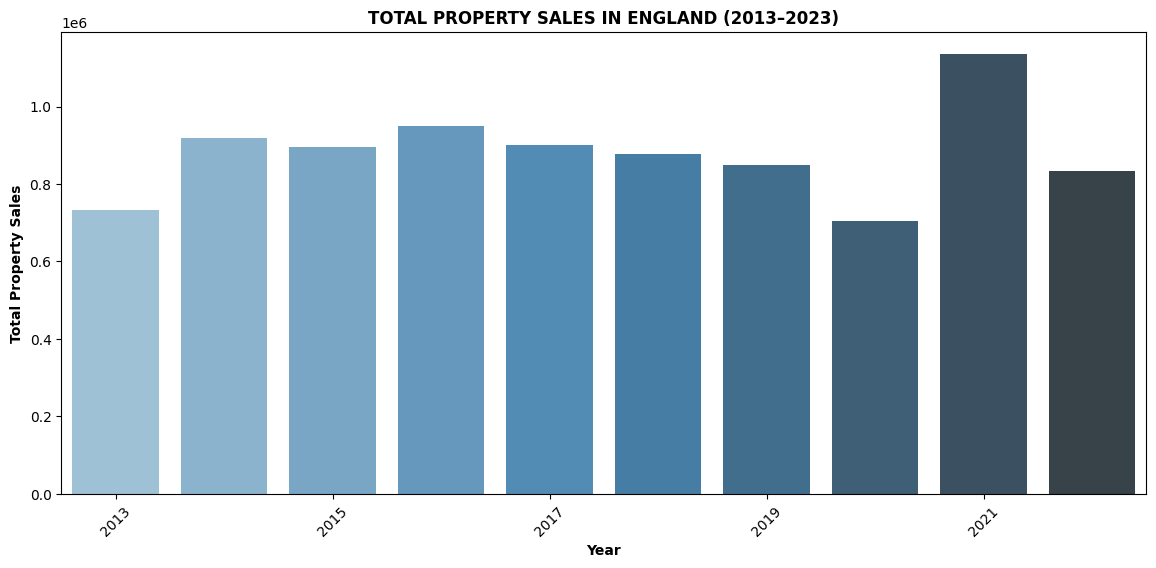

In [27]:

# INSTEAD OF THE TOTAL, ADD THE AVERAGE HERE...

# 1. Extract the row labeled 'England_sum_year'
sum_row = Sales_England[Sales_England['DISTRICT'] == 'ENGLAND_TOTAL_YEAR']

# 2. Select only columns that look like years (e.g. '1996' to '2023')
year_columns = [col for col in sum_row.columns if col.isnumeric()]
year_data = sum_row[year_columns].squeeze()

# 3. Plot
plt.figure(figsize=(14, 6))
sns.barplot(x=year_data.index, y=year_data.values, palette='Blues_d')

# 4. Customize x-axis ticks (every 2 years)
plt.xticks(ticks=np.arange(0, len(year_data), 2), labels=year_data.index[::2], rotation=45)

# 5. Labels and title
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Total Property Sales", fontweight='bold')
plt.title("TOTAL PROPERTY SALES IN ENGLAND (2013–2023)", fontweight='bold')

# 6. Show it
plt.tight_layout()
plt.show()


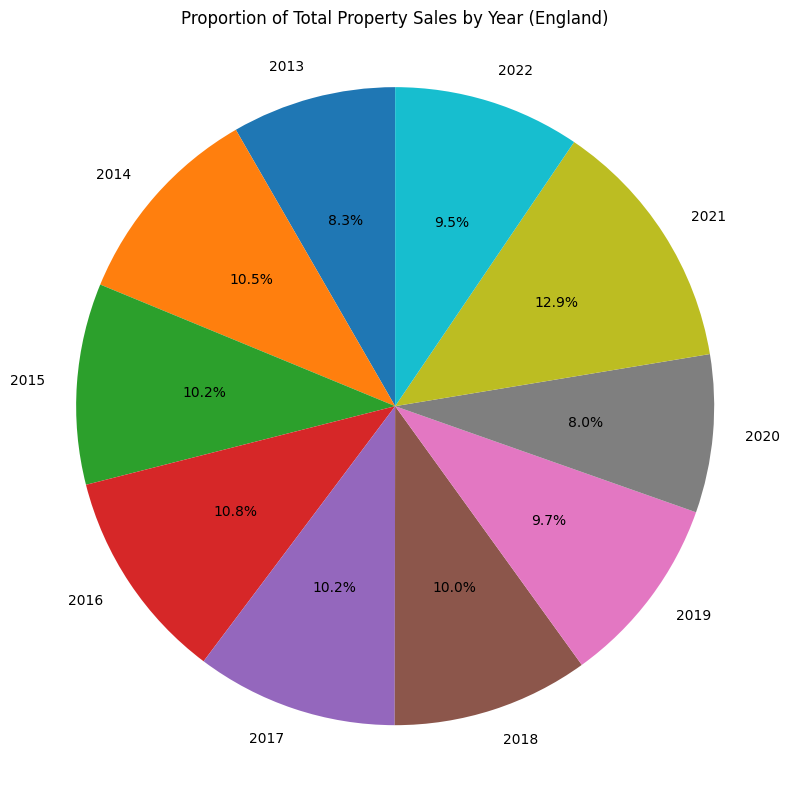

In [30]:

# 1. Extract the England sum row
sum_row = Sales_England[Sales_England['DISTRICT'] == 'ENGLAND_TOTAL_YEAR']

# 2. Select only the year columns (numeric string names like '1996', '1997', ...)
year_columns = [col for col in sum_row.columns if col.isnumeric()]
year_data = sum_row[year_columns].squeeze()

# 3. Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    year_data.values,
    labels=year_data.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Proportion of Total Property Sales by Year (England)')
plt.axis('equal')  # Keeps the pie circular
plt.tight_layout()
plt.show()

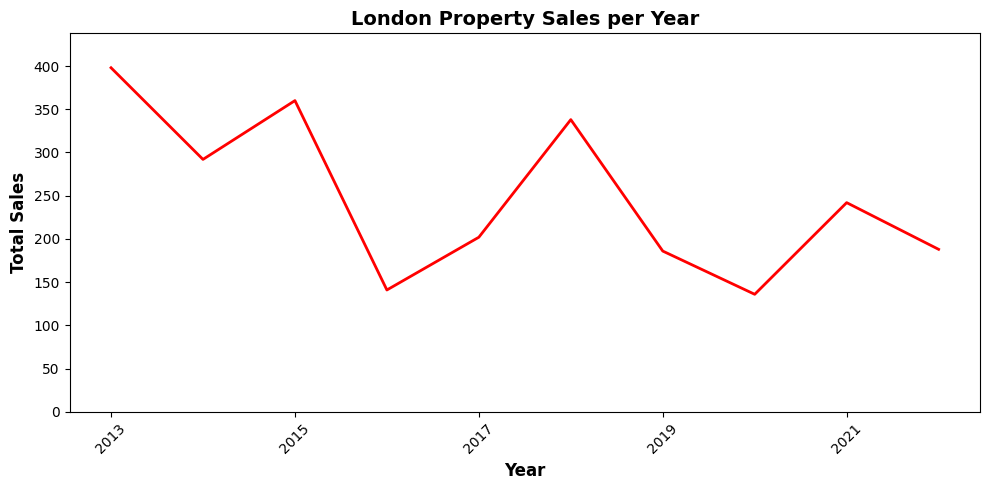

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter only London districts (case-insensitive)
london_df = Sales_England[Sales_England['DISTRICT'].str.contains('london', case=False)]

# 2. Get year columns (e.g., '1996' to '2023')
year_columns = [col for col in london_df.columns if col.isnumeric()]

# 3. Sum sales across all London districts for each year
london_yearly_sales = london_df[year_columns].sum()

# 4. Convert year labels to integers for proper numeric plotting
x_years = london_yearly_sales.index.astype(int)
y_sales = london_yearly_sales.values

# 5. Create the figure with a clean white background
plt.figure(figsize=(10, 5), facecolor='white')

# 6. Plot the red sales trend line
plt.plot(x_years, y_sales, color='red', linewidth=2)

# 7. Add formal title and axis labels
plt.title("London Property Sales per Year", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Total Sales", fontsize=12, fontweight='bold')

# 8. X-axis: show every 2 years, with rotated labels
tick_years = np.arange(x_years.min(), x_years.max() + 1, 2)
plt.xticks(ticks=tick_years, rotation=45, fontsize=10)

# 9. Y-axis: proportional scaling with slight padding
plt.ylim(0, y_sales.max() * 1.1)
plt.yticks(fontsize=10)

# 10. Clean visual: no gridlines
plt.grid(False)

# 11. Tight layout and high-resolution export
plt.tight_layout()
plt.savefig("london_property_sales_trend_clean.png", dpi=300, bbox_inches='tight')

# 12. Display the plot
plt.show()


<Figure size 1600x600 with 0 Axes>

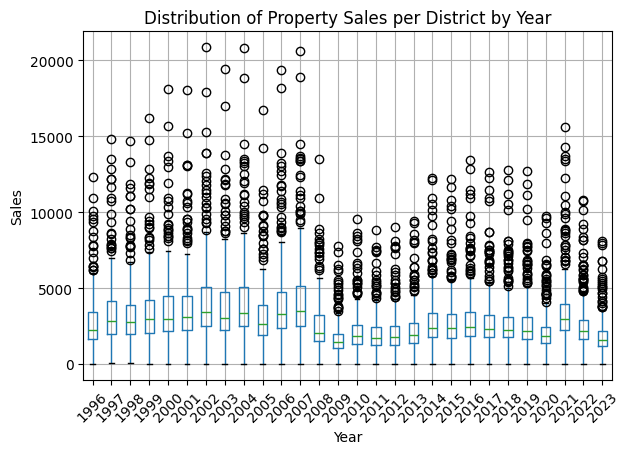

In [ ]:
import matplotlib.pyplot as plt

# Assuming melted is prepared like before (one row per LAD per year)
year_columns = [col for col in Sales_England.columns if col.isnumeric()]
data_clean = Sales_England[~Sales_England['DISTRICT'].str.contains('England_sum', case=False)]
melted = data_clean.melt(id_vars='DISTRICT', value_vars=year_columns, var_name='Year', value_name='Sales')

# Matplotlib boxplot grouped by year
plt.figure(figsize=(16, 6))
melted.boxplot(column='Sales', by='Year')
plt.title("Distribution of Property Sales per District by Year")
plt.suptitle("")  # Remove default matplotlib group title
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

<ipython-input-34-3fe0d6d0a530>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TOTAL_SALES_LAD_', y='DISTRICT', data=top_districts, palette='viridis')


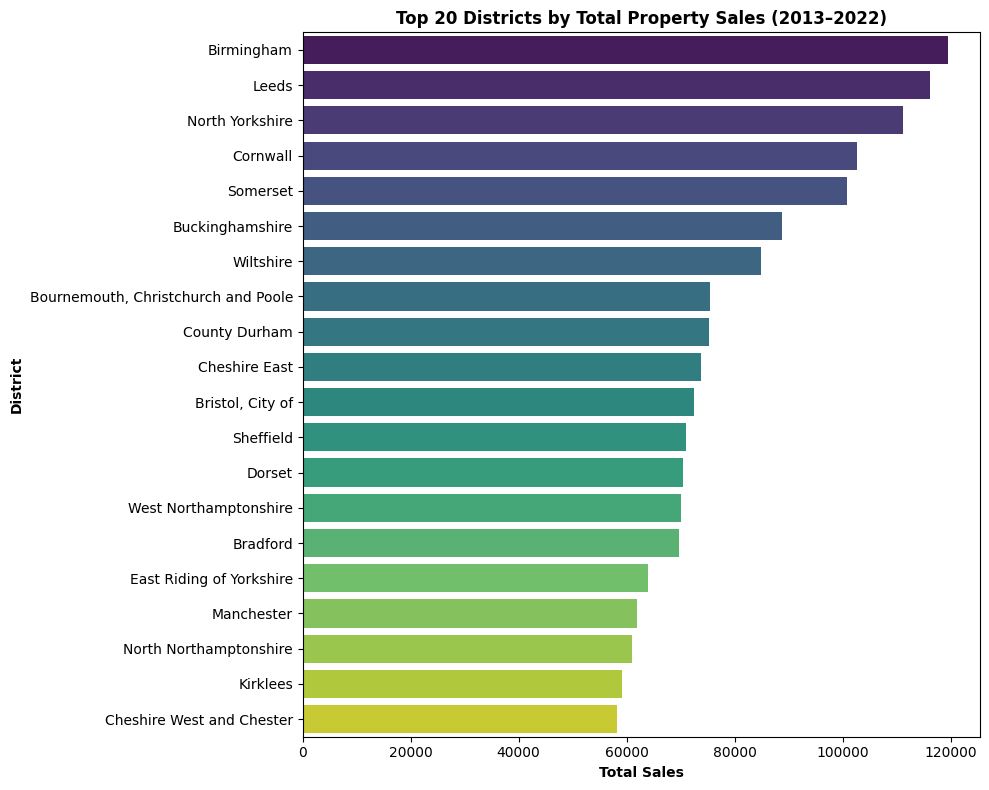

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Remove summary row (where DISTRICT == 'ENGLAND_TOTAL_YEAR')
filtered_sales = Sales_England[Sales_England['DISTRICT'] != 'ENGLAND_TOTAL_YEAR']

# 2. Sort by total sales and select top 20 districts
top_districts = filtered_sales.sort_values('TOTAL_SALES_LAD_', ascending=False).head(20)

# 3. Create the bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='TOTAL_SALES_LAD_', y='DISTRICT', data=top_districts, palette='viridis')

# 4. Customize labels and layout
plt.title("Top 20 Districts by Total Property Sales (2013–2022)", fontweight='bold')
plt.xlabel("Total Sales", fontweight='bold')
plt.ylabel("District", fontweight='bold')
plt.tight_layout()

# 5. Show the chart
plt.show()


In [ ]:
# How many years does the anlysis include?
# Which years had the highest sales rate? And which district in England?
# Create new columns: Total sales per district and average per district
# Create new row: Total sales per year. Name area: Annual Sales in England or recallculate 'country: England'
# eliminate the word before the districts name e.g. ladu2023:Hartlepool
# Add histogram
# Add scatterplot
# WHO IS MAY AUDIENCE?
#
#
#
#

**MARKDOWN-NON-SPATIAL-VISUALISATION**

## References
<p><a href="add_url_here">[1]</a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2]</a>GEOG5990M course materials</p>
<p><a href="add_url_here">[3]</a>Citation 3</p>